# RL Market Maker — Feature Engineering for Linear Function Approximation (VFA)

In [1]:
%pip install yfinance pandas numpy matplotlib tqdm --quiet
import warnings; warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import yfinance as yf
from utils.charts import MarketCharts

tickers = ['BTC-EUR', 'C3M.MI', 'VWCE.DE',]
BENCHMARK_ASSET = 'VWCE.DE'

print(f'Downloading historical data for {tickers}...')
df_prices = yf.download(tickers, start='2015-01-01', end='2026-07-01')['Close']
df_prices = df_prices.dropna()
print('Data loaded successfully! Shape:', df_prices.shape)

df_normalized = (df_prices / df_prices.iloc[0]) * 100

import os; os.makedirs("data", exist_ok=True)
df_normalized.to_csv("data/df_normalized.csv")
print("Saved df_normalized -> data/df_normalized.csv", df_normalized.shape)


[*********************100%***********************]  3 of 3 completed

Data loaded successfully! Shape: (1753, 3)
Saved df_normalized -> data/df_normalized.csv (1753, 3)


## Environment exploration

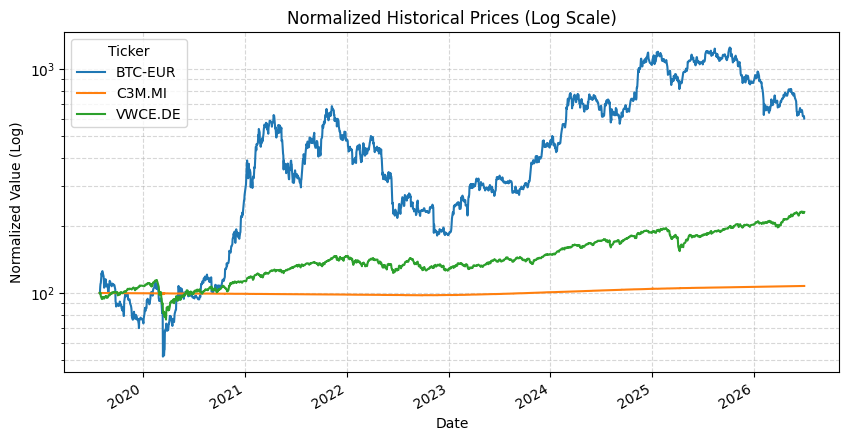

Asset      | Step         | Revenue 1Y   | Volatility 1Y     
--------------------------------------------------------------
BTC-EUR    |     0.1746% |      55.22% |           59.95%
C3M.MI     |     0.0041% |       1.05% |            0.85%
VWCE.DE    |     0.0528% |      14.22% |           16.18%


In [3]:
MarketCharts.plot_normalized_prices(df_normalized)

import numpy as np
returns = df_prices.pct_change().dropna()
mu_values = returns.mean().values
cov_matrix = returns.cov().values  
giorni_finanziari = 252

print(f"{'Asset':<10} | {'Step':<12} | {'Revenue 1Y':<12} | {'Volatility 1Y':<18}")
print("-" * 62)

for i, mu in enumerate(mu_values):
    asset_name = df_prices.columns[i] if hasattr(df_prices, 'columns') else f"Asset {i+1}"
    
    step_pct = mu * 100
    annual_pct = ((1 + mu) ** giorni_finanziari - 1) * 100
    daily_vol = np.sqrt(cov_matrix[i, i])
    annual_vol = daily_vol * np.sqrt(giorni_finanziari) * 100
    
    print(f"{asset_name:<10} | {step_pct:>10.4f}% | {annual_pct:>10.2f}% | {annual_vol:>15.2f}%")

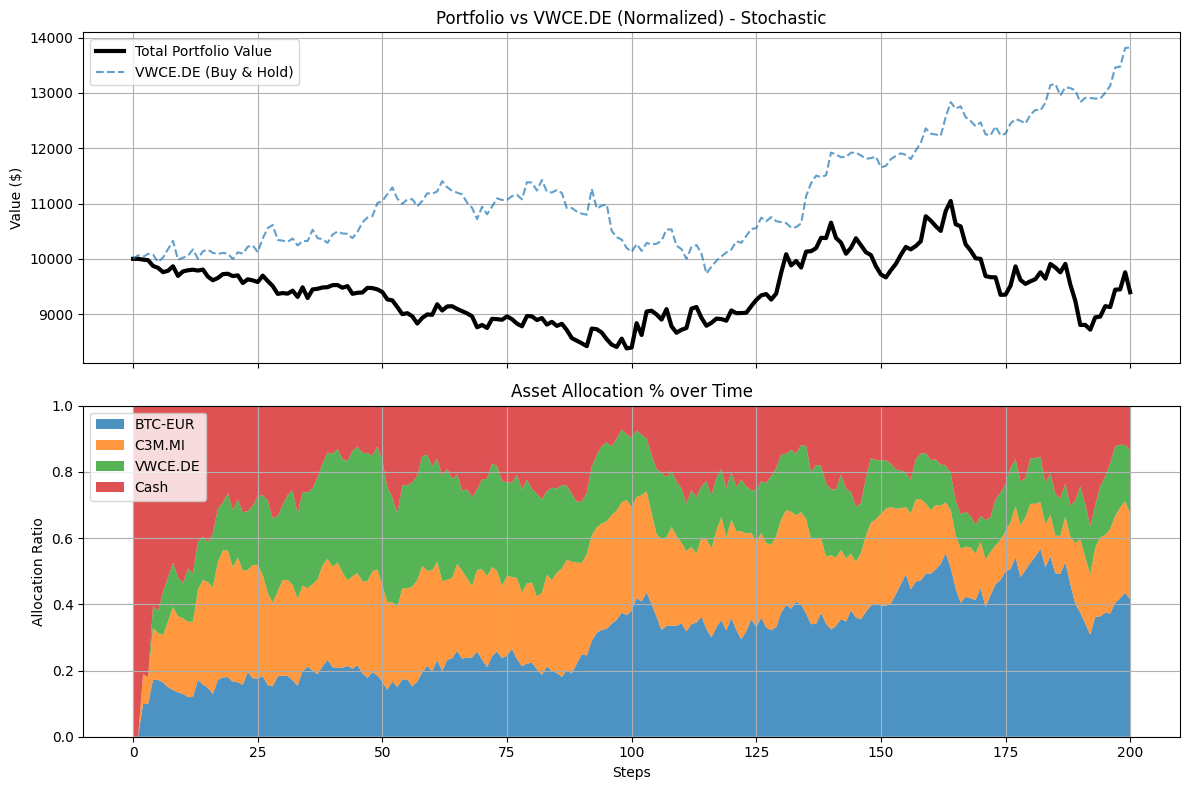

In [4]:
from envs.market import MarketEnv

history_rsi, history_corr = [], []
history_portfolio, history_port_std = [], []
history_prices, history_regime = [], []
history_macd = []

env_hist = MarketEnv(df_prices=df_normalized, stochastic=True, regime_changing=True)
obs, info = env_hist.reset(seed=42)
for step in range(200):
    action = env_hist.action_space.sample()
    obs, reward, terminated, truncated, info = env_hist.step(action)
    history_rsi.append(info['rsi'])
    history_corr.append(info['correlation'])
    history_portfolio.append(info['portfolio_value'])
    history_port_std.append(info['port_std'])
    history_prices.append(info['prices'])
    history_regime.append(info['regime'])
    history_macd.append(info['macd'])
    if step % 10 == 0:
        env_hist.render(benchmark_asset=BENCHMARK_ASSET)
        time.sleep(0.05)
env_hist.render(benchmark_asset=BENCHMARK_ASSET)

# Features Exploration

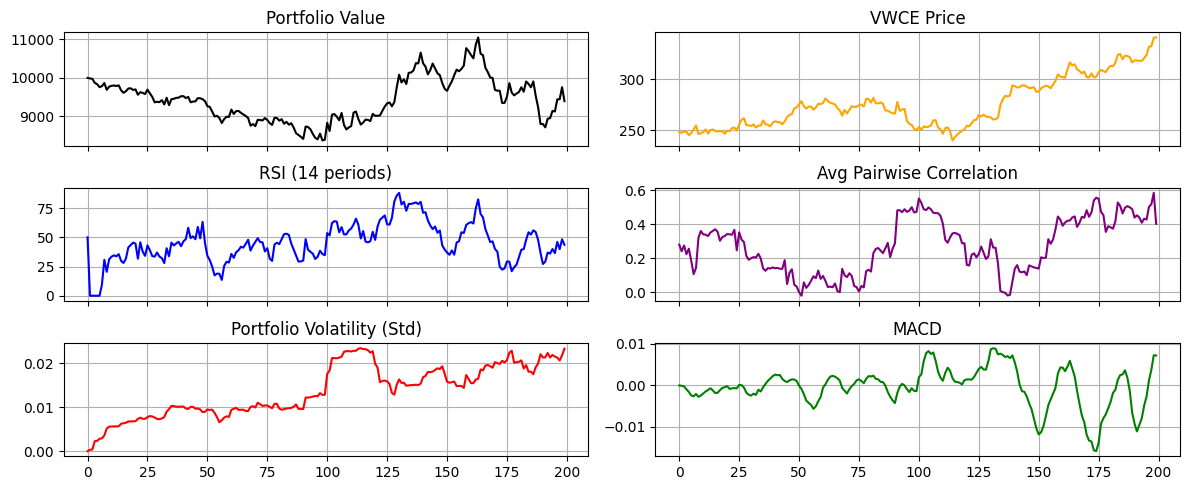

In [5]:
MarketCharts.plot_market_env_history(history_portfolio, history_prices, history_rsi, history_corr, history_port_std, history_macd)

## Calibration of Bounds for every Feature

In [6]:
def make_env():
    return MarketEnv(df_prices=df_normalized, stochastic=False, regime_changing=False)

def make_env_stochastic():
    return MarketEnv(df_prices=df_normalized, stochastic=True, regime_changing=True)

from utils.calibration import FeatureCalibration
# ---- Feature-range calibration 
FeatureCalibration.calibrate_feature_ranges(make_env_stochastic)


idx  name             min         max          p1         p99
  6  cash          0.0681      1.0000      0.1034      0.6315
  7  rsi           0.0000    100.0000      3.8639     80.9974
  9  vol           0.0000      0.0306      0.0018      0.0265
 10  macd         -0.0257      0.0154     -0.0139      0.0109


## Linear-FA SARSA agent


In [7]:
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures
from utils.training import train, evaluate

N_EPISODES         = 1000
EVAL_EVERY         = 50
EVAL_EPISODES      = 20
MAX_STEPS_PER_EP   = 250
EVAL_MAX_STEPS     = 250
MASTER_SEED        = 42
NOMINAL_ALPHA      = 0.1

TC_N_TILES   = [5, 5, 5, 5]
TC_N_TILINGS = 4
TC_ALPHA     = NOMINAL_ALPHA / TC_N_TILINGS 

RBF_N_CENTERS = [4, 4, 4, 4]
RBF_SIGMA     = 0.1
RBF_ALPHA     = NOMINAL_ALPHA

POLY_ALPHA    = 0.0001 

N_SEEDS = 1  

## Features Sets

In [8]:
from experiments.feature_configs import FEATURE_CONFIGS, make_feature_extractor

feature_sets = FEATURE_CONFIGS
print(f"Loaded {len(feature_sets)} feature configurations.\n")

for cfg in feature_sets:
    feat = make_feature_extractor(cfg, seed=0)
    print(f"{cfg['name']}, n_features = {feat.n_features}, alpha = {cfg['alpha']}")


Loaded 8 feature configurations.

Set A - Raw (prices), n_features = 3, alpha = 0.0001
Set A - TileCoder (Raw Prices), n_features = 500, alpha = 0.025
Set B - TileCoder (asset allocation), n_features = 2500, alpha = 0.025
Set B - Polynomial (asset allocation), n_features = 15, alpha = 0.0001
Set C - TileCoder (MACD, port_std, RSI), n_features = 320, alpha = 0.025
Set C - Polynomial (RSI, MACD, port_std), n_features = 10, alpha = 0.0001
Set C - RBF (port_std, RSI, MACD), n_features = 64, alpha = 0.1
Set D - TileCoder (MACD, port_std), n_features = 144, alpha = 0.025


## Training

In [9]:
def train_one(feat_extractor, alpha, label):
    """Train a fresh agent on a fresh env for one seed."""
    env_train = make_env_stochastic()
    env_eval  = make_env_stochastic()
    agent = LinearSARSAAgent(
        action_space=env_train.action_space,
        feature_extractor=feat_extractor,
        alpha=alpha,
        epsilon_start=1.0,
        epsilon_decay=0.997,
        epsilon_min=0.05,
        seed=MASTER_SEED,
    )
    history = train(
        agent, env_train, n_episodes=N_EPISODES,
        max_steps_per_episode=MAX_STEPS_PER_EP,
        eval_every=EVAL_EVERY,
        eval_max_steps=EVAL_MAX_STEPS,
        eval_episodes=EVAL_EPISODES,
        eval_env=env_eval,
        seed=MASTER_SEED,
        progress=True,
    )
    print(f'[{label}] final eval return = {history.eval_mean_returns[-1]:.4f}')
    return agent, history

results = {}
trained_agents = {}
for cfg in feature_sets[1:2]:
    label = cfg["name"]
    alpha = cfg["alpha"]
    print(f'\n=== {label} ===')
    seed_runs = []
    trained_agents[label] = []
    for s in range(N_SEEDS):
        f = make_feature_extractor(cfg, seed=s)
        agent, hist = train_one(f, alpha, f'{label} seed={s}')
        seed_runs.append(hist)
        trained_agents[label].append(agent)
    results[label] = seed_runs



=== Set A - TileCoder (Raw Prices) ===


Training:   0%|          | 0/1000 [00:00<?, ?ep/s]

[Set A - TileCoder (Raw Prices) seed=0] final eval return = 0.1615


## Final performance

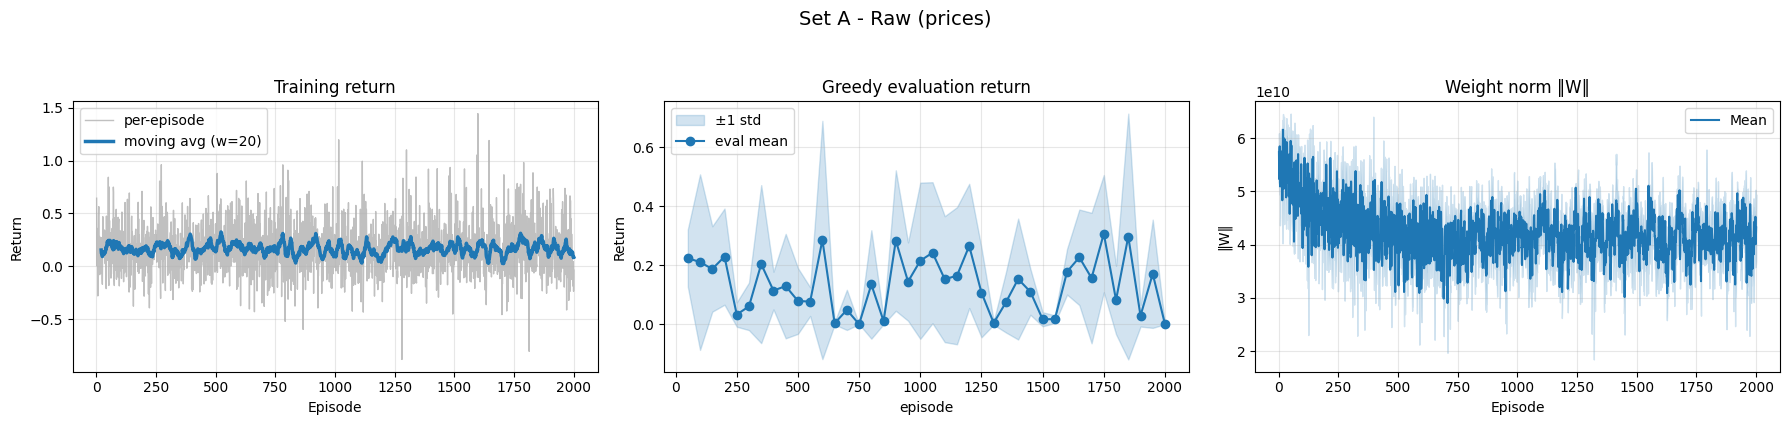

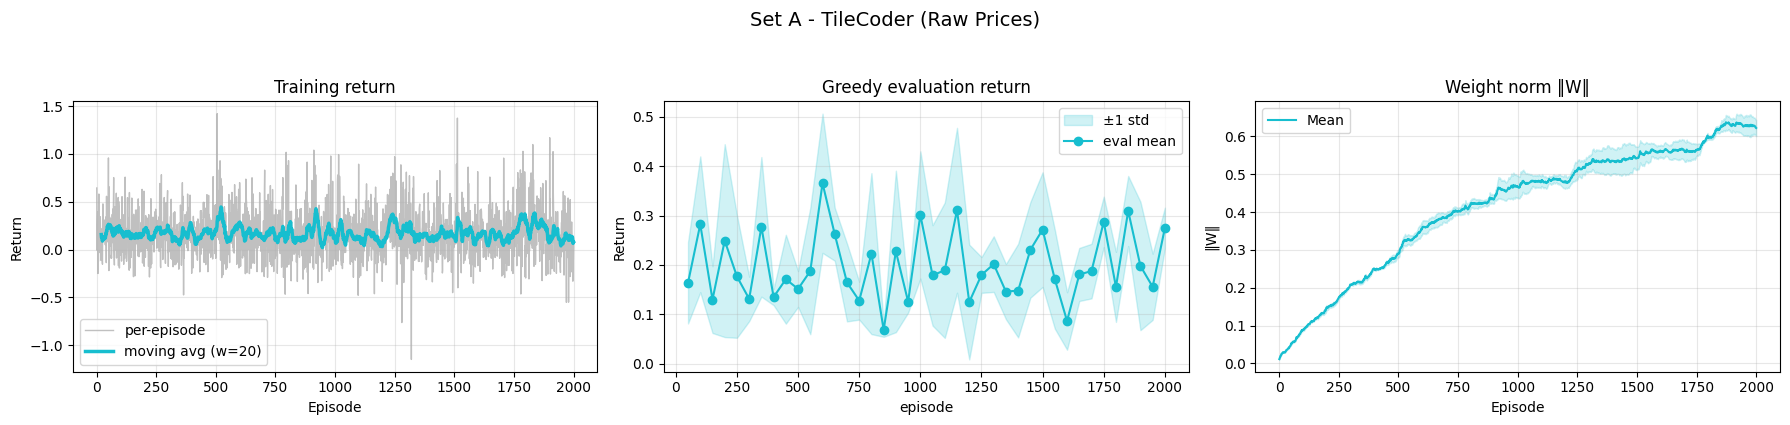

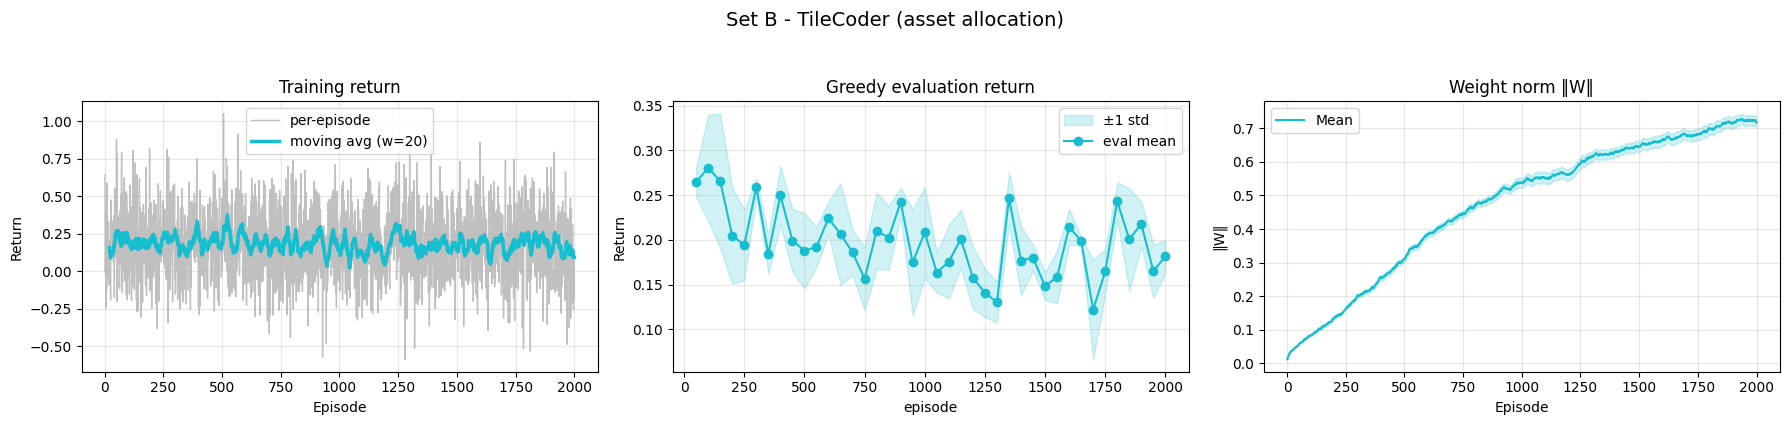

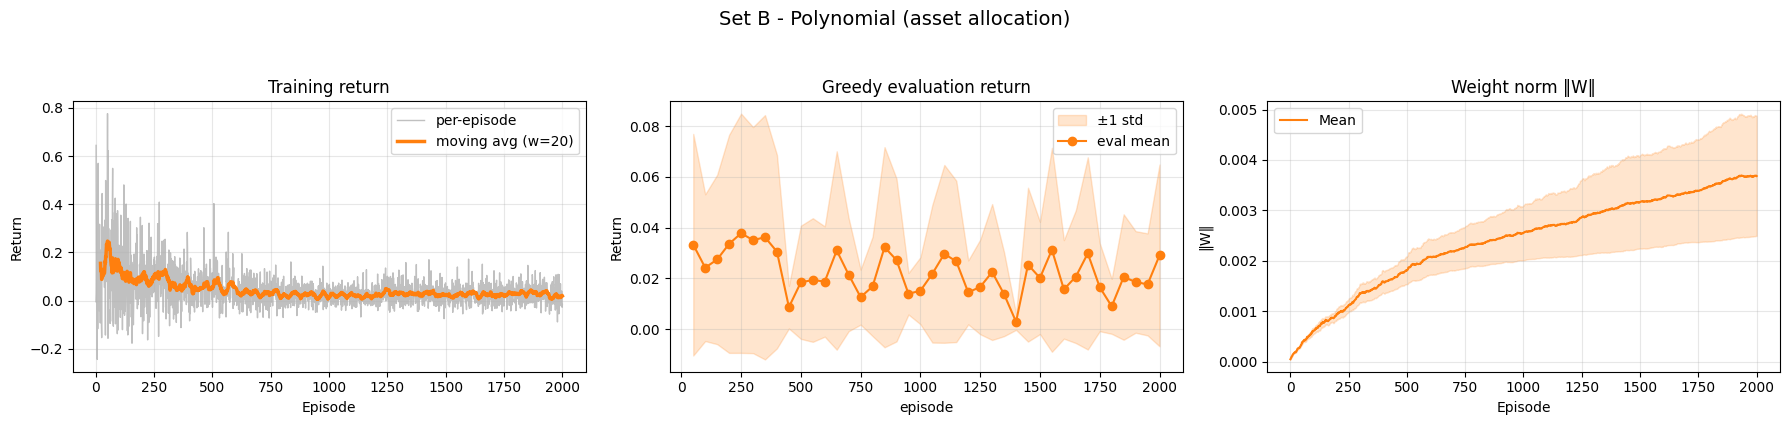

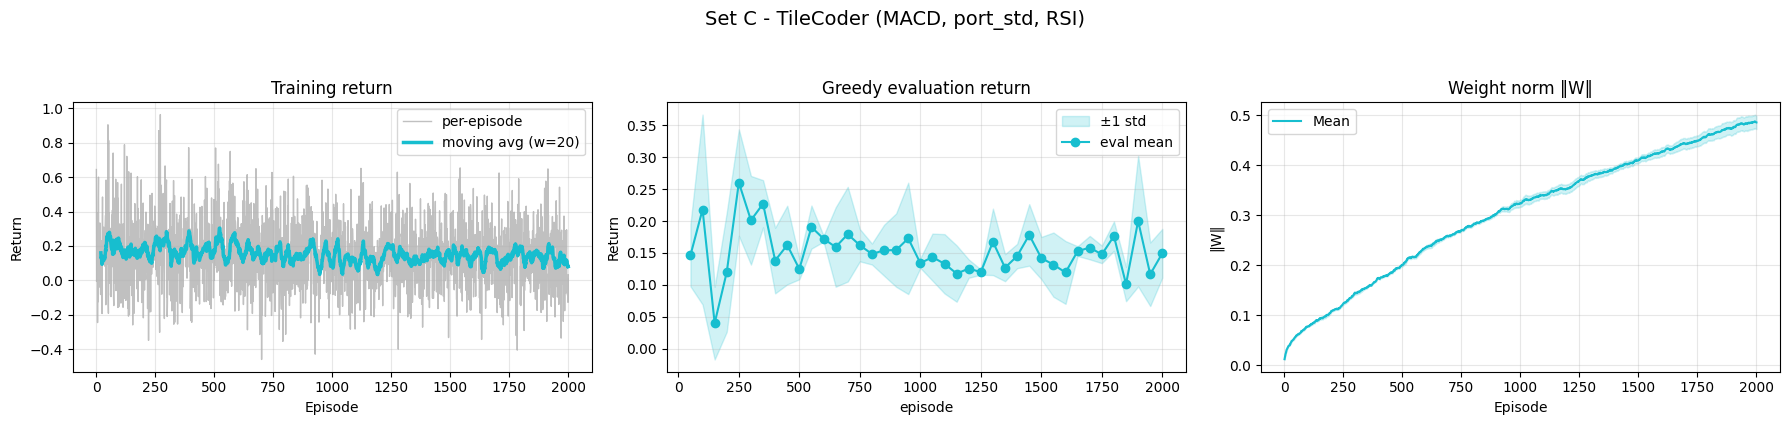

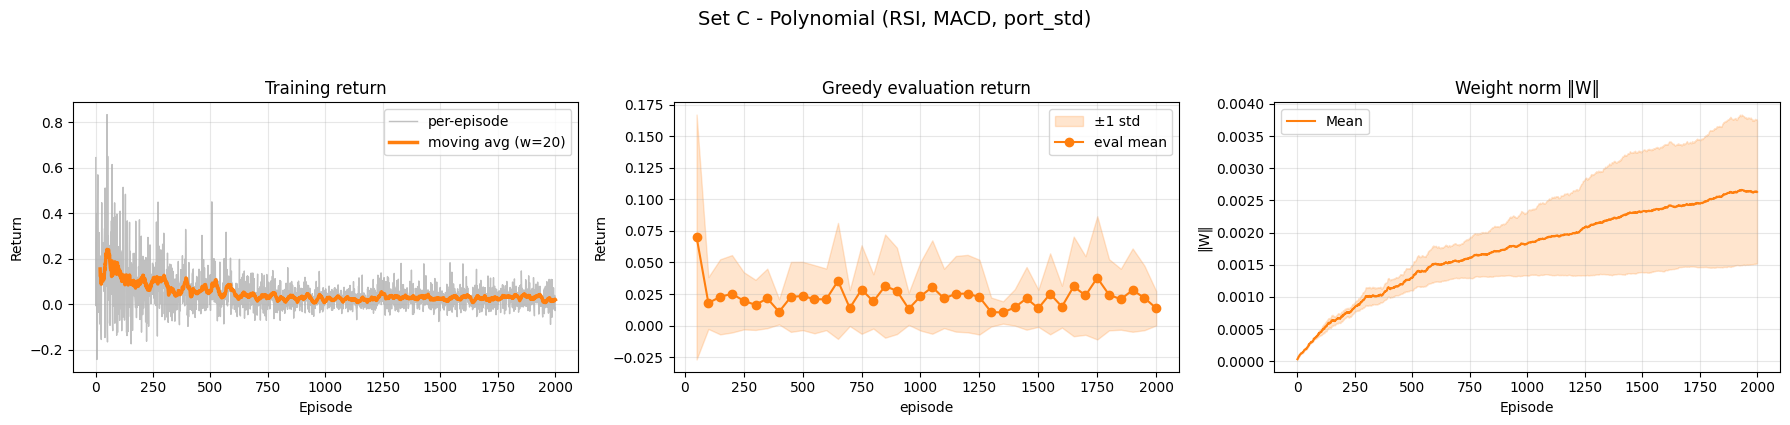

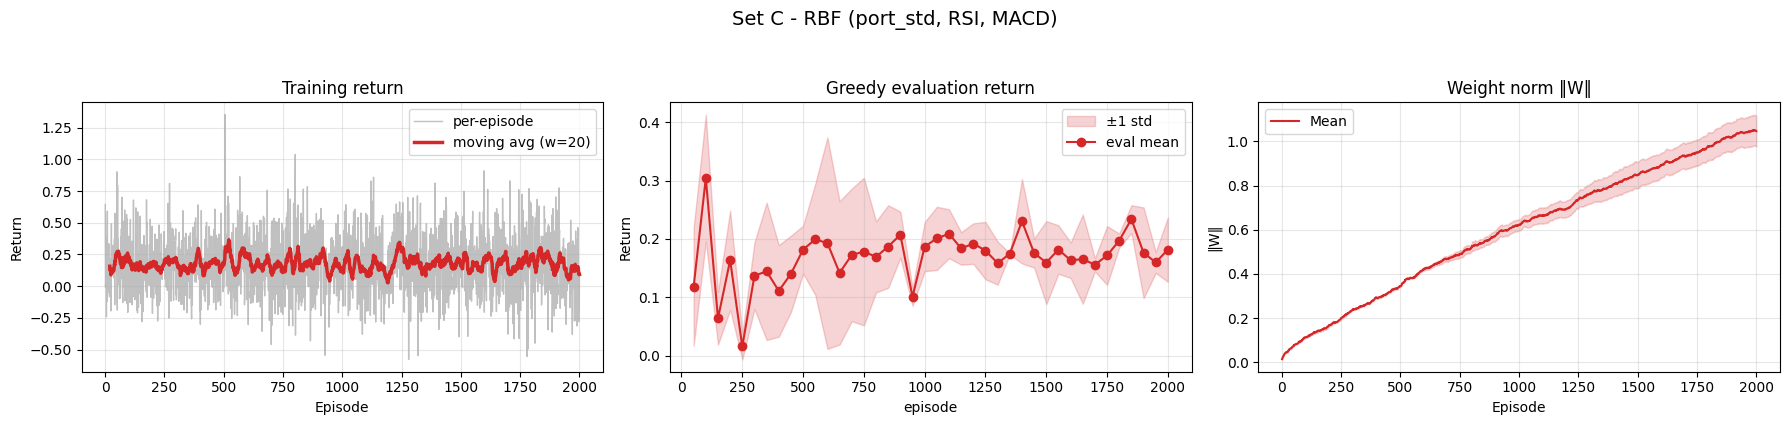

No history files found for Set D - TileCoder (MACD, port_std) in stoch_regime__20260726_155844!


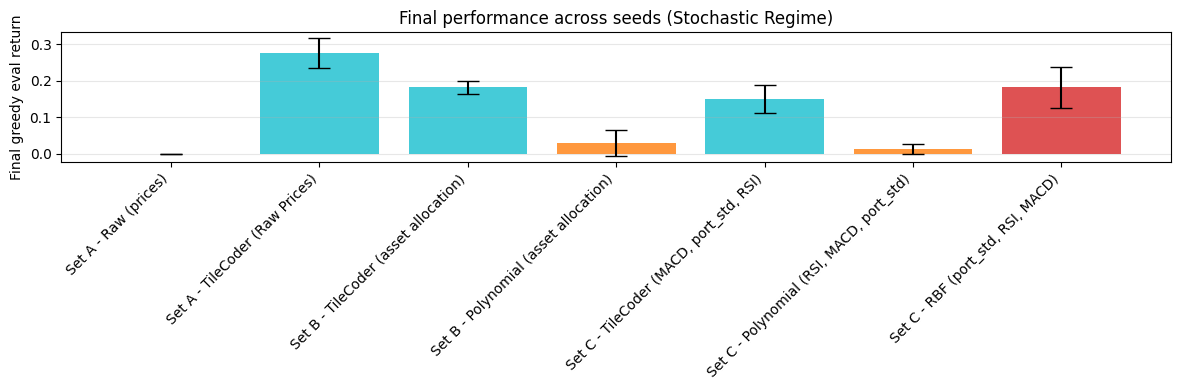

In [10]:
feature_sets_experiments = {}
for cfg in feature_sets:
    label = cfg['name']
    kind = cfg['kind']
    alpha = cfg['alpha']
    if kind == 'tile':
        color = 'tab:cyan'
    elif kind == 'poly':
        color = 'tab:orange'
    elif kind == 'rbf':
        color = 'tab:red'
    else:
        color = 'tab:blue'
    
    feat = make_feature_extractor(cfg, seed=0)
    
    feature_sets_experiments[label] = {
        'features': feat,
        'alpha': alpha,
        'color': color
    }

result_dir = "stoch_regime__20260726_155844"
final_evals = MarketCharts.plot_training_trajectories(feature_sets_experiments, result_dir)
MarketCharts.plot_final_performance(final_evals, feature_sets_experiments)


## Greedy rollout

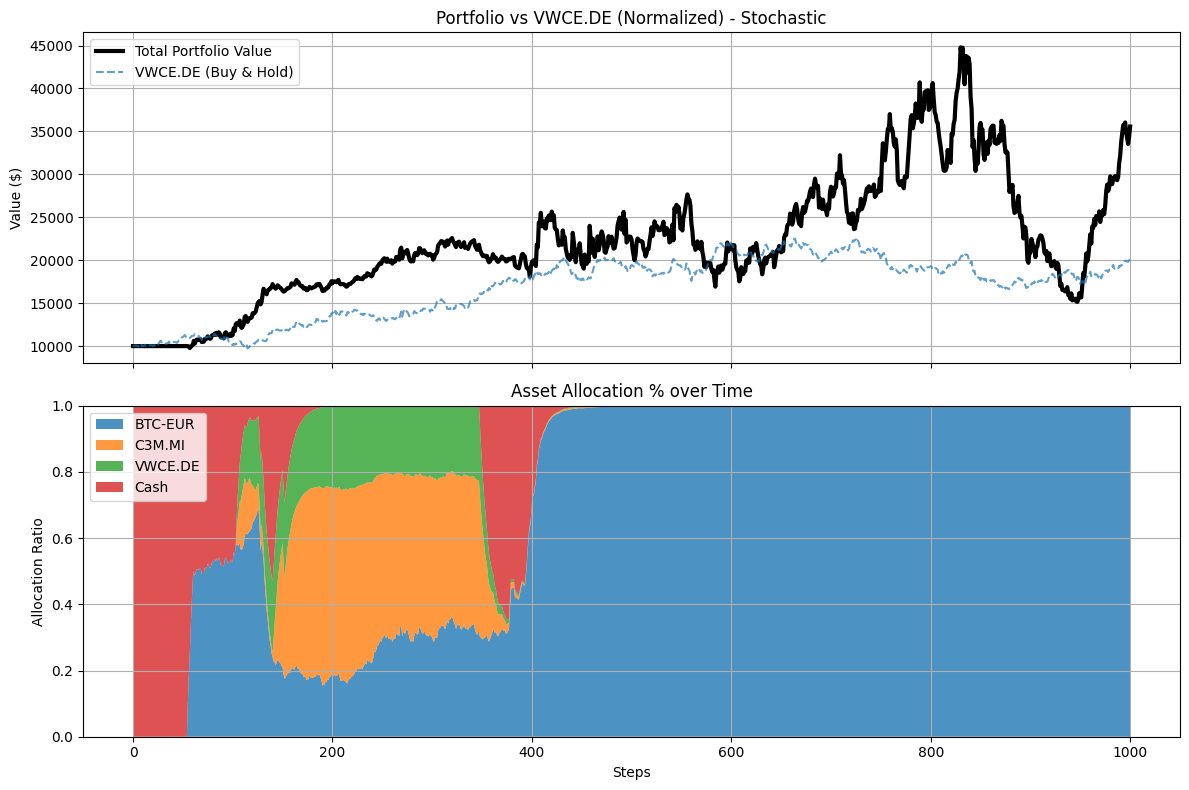

In [40]:
def render_rollout(agent):
    env_eval = make_env_stochastic()
    agent.epsilon = 0.0
    obs, _ = env_eval.reset(seed=MASTER_SEED)
    for step in range(1000):
        a_flat = agent.select_action(obs, greedy=True)
        obs, _, _, _, _ = env_eval.step(a_flat)
        if step % 100 == 0:
            env_eval.render(benchmark_asset=BENCHMARK_ASSET)
            time.sleep(0.05)
    env_eval.render(benchmark_asset=BENCHMARK_ASSET)
    return env_eval

cfg = feature_sets[1] # Tiling Asset Allocation
label = cfg['name']
agent = trained_agents[label][0]
render_rollout(agent)

## Visualising the Value Function Structure (2D Heatmaps)

Quickly training agents to populate weights for visualization...


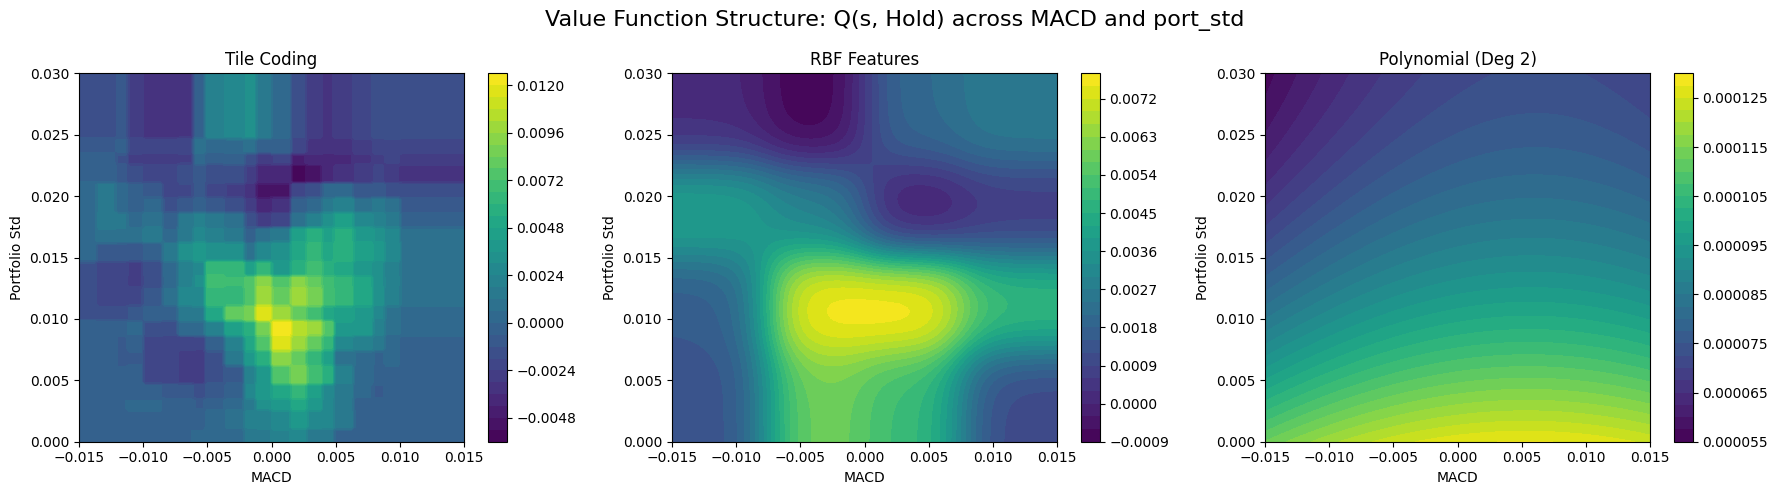

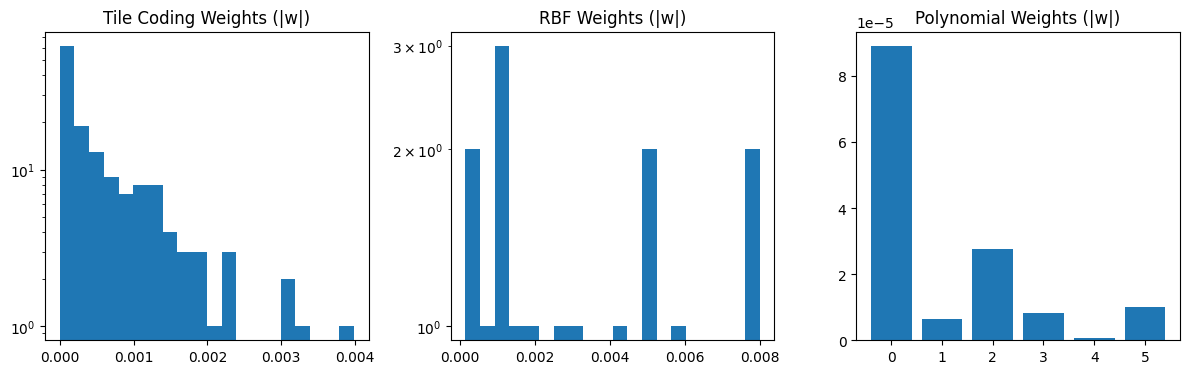

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures
from utils.training import train
env_viz = make_env_stochastic()
MACD_IDX = 10
PORT_STD_IDX = 9

feat_tc = TileCoder(
    low=np.array([-0.015,0]),
    high=np.array([0.015,0.03]),
    n_tiles=[6,6],
    n_tilings=4,
    feature_indices=[MACD_IDX, PORT_STD_IDX],
)

feat_rbf = RBFFeatures(
    low=np.array([-0.015,0]),
    high=np.array([0.015,0.03]),
    n_centers=[4,4],
    sigma=RBF_SIGMA,
    normalize=True,
    feature_indices=[MACD_IDX, PORT_STD_IDX]
)

feat_poly = PolynomialFeatures(
    state_dim=11, degree=2,
    feature_indices=[MACD_IDX, PORT_STD_IDX],
    low=np.array([-0.015,0]),
    high=np.array([0.015, 0.03])
)

agents = {
    "Tile Coding": LinearSARSAAgent(feature_extractor=feat_tc, action_space=env_viz.action_space, alpha=NOMINAL_ALPHA / TC_N_TILINGS),
    "RBF Features": LinearSARSAAgent(feature_extractor=feat_rbf, action_space=env_viz.action_space, alpha=NOMINAL_ALPHA),
    "Polynomial (Deg 2)": LinearSARSAAgent(feature_extractor=feat_poly, action_space=env_viz.action_space, alpha=POLY_ALPHA)
}

print("Quickly training agents to populate weights for visualization...")
for name, agent in agents.items():
    train(agent, env_viz, n_episodes=100, max_steps_per_episode=250, progress=False)

# Setup 2D Grid
macd_vals = np.linspace(-0.015, 0.015, 100)
port_std_vals = np.linspace(0, 0.03, 100)
MACD, PORT_STD = np.meshgrid(macd_vals, port_std_vals)

base_state = env_viz.reset()[0]
HOLD_ACTION = 13  # Hold all assets

MarketCharts.plot_value_function_heatmaps(agents, base_state, MACD_IDX, PORT_STD_IDX)
MarketCharts.plot_weight_sparsity(agents)

## State visitation and action choice

Skipping Set D - TileCoder (MACD, port_std), no files found.


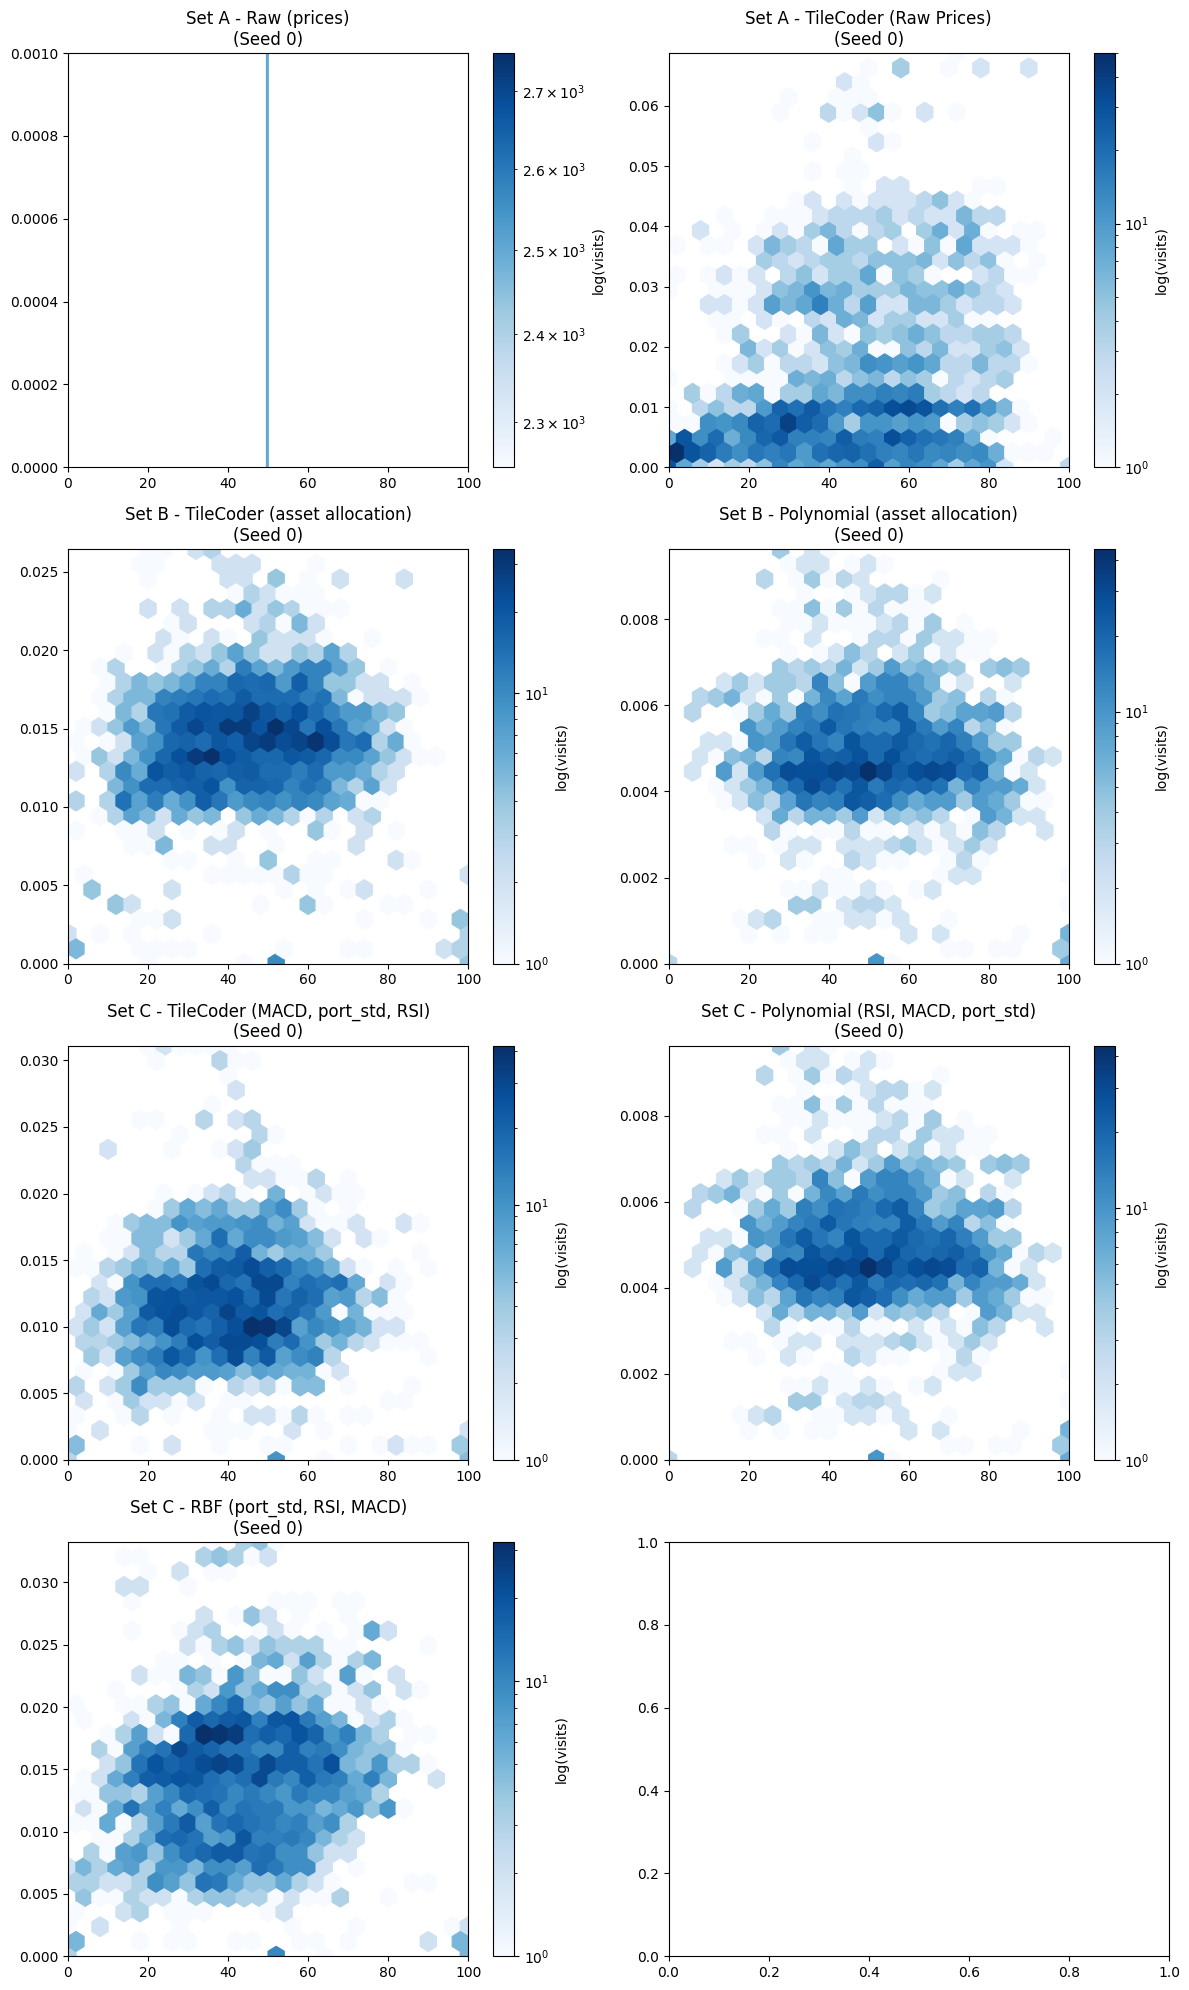


=== Top 5 Most Used Actions per Agent ===

Agent: Set A - Raw (prices)
Action ID   Description (Asset 0/1/2)     Count     % of Total
-----------------------------------------------------------------
(1, 1, 1)   Hold / Hold / Hold            2500      100.0%

Agent: Set A - TileCoder (Raw Prices)
Action ID   Description (Asset 0/1/2)     Count     % of Total
-----------------------------------------------------------------
(2, 0, 0)   Buy / Sell / Sell             586        23.4%
(1, 2, 1)   Hold / Buy / Hold             541        21.6%
(0, 1, 1)   Sell / Hold / Hold            478        19.1%
(0, 1, 2)   Sell / Hold / Buy             341        13.6%
(1, 0, 2)   Hold / Sell / Buy             234         9.4%

Agent: Set B - TileCoder (asset allocation)
Action ID   Description (Asset 0/1/2)     Count     % of Total
-----------------------------------------------------------------
(2, 1, 2)   Buy / Hold / Buy              862        34.5%
(1, 1, 0)   Hold / Hold / Sell            71

In [13]:
from agents.linear_sarsa import LinearSARSAAgent
from utils.features import TileCoder, RBFFeatures, PolynomialFeatures

result_dir = "stoch_regime__20260726_155844"

MarketCharts.plot_state_visitation_and_actions(
    feature_sets_experiments, result_dir, 
    make_env_stochastic, LinearSARSAAgent, 
    TileCoder, RBFFeatures, PolynomialFeatures,
    TC_N_TILINGS, RBF_SIGMA, MASTER_SEED
)

Loaded 21 runs across 7 configs


,mean,std,count
config,,,
Set A - TileCoder (Raw Prices),0.274712,0.050537,3
"Set C - RBF (port_std, RSI, MACD)",0.181727,0.067733,3
Set B - TileCoder (asset allocation),0.181471,0.022519,3
"Set C - TileCoder (MACD, port_std, RSI)",0.149628,0.046718,3
Set B - Polynomial (asset allocation),0.029017,0.043886,3
"Set C - Polynomial (RSI, MACD, port_std)",0.013754,0.016682,3
Set A - Raw (prices),0.000000,0.000000,3


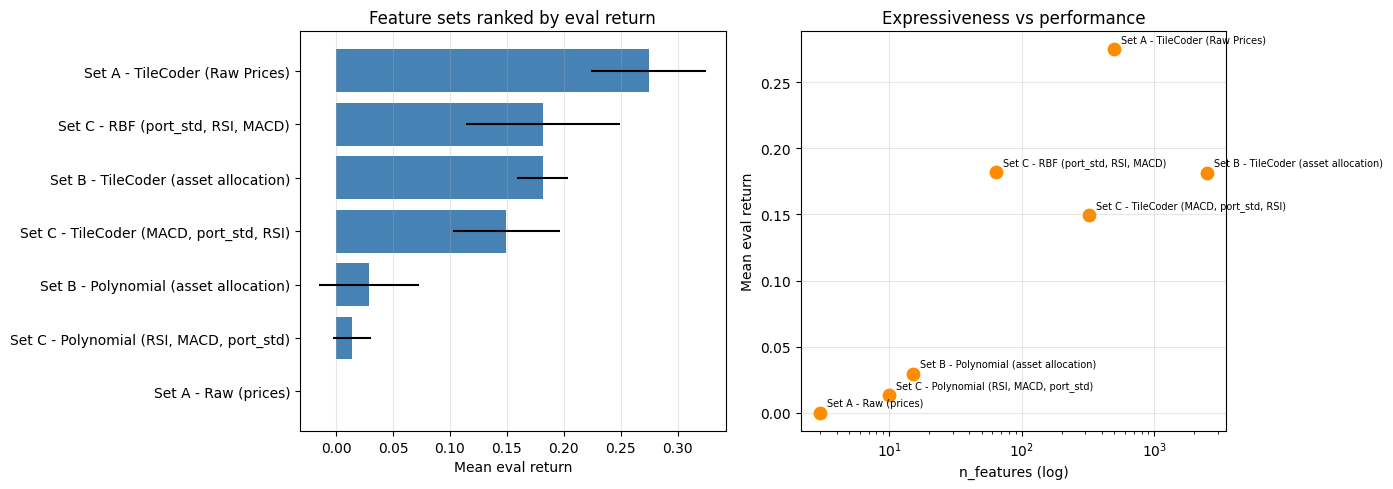

In [14]:
from experiments.feature_configs import load_results

df = load_results("results/feature_sweep__stoch_regime__20260726_155844.csv")
MarketCharts.plot_feature_sweep_results(df)

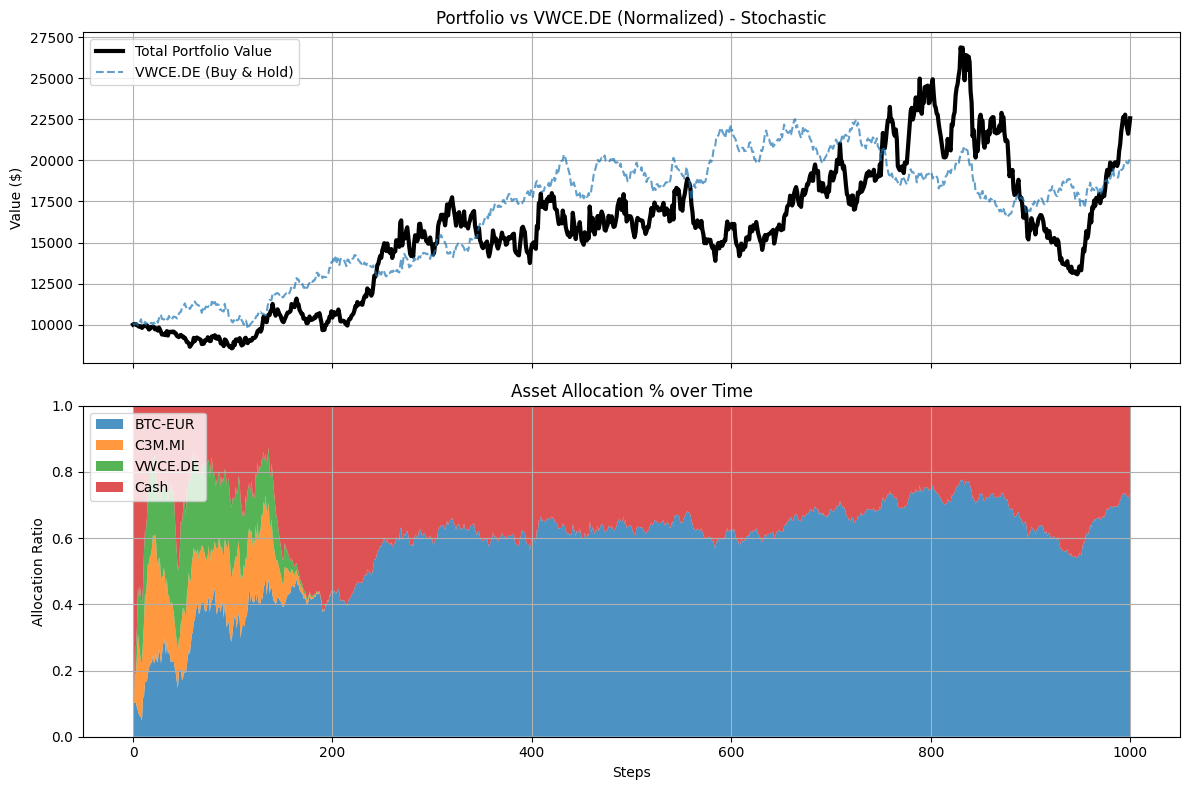

In [45]:
import numpy as np
import glob
from experiments.feature_configs import _safe_name


result_dir = "stoch_regime__20260726_155844"  

label = "Set A - TileCoder (Raw Prices)"
config_info = feature_sets_experiments[label]
feat = config_info['features']
safe_label = _safe_name(label)

files = glob.glob(f"results/histories/{result_dir}/{safe_label}__seed1.npz")

if not files:
    print(f"Could not find npz file for {label}")
else:
    data = np.load(files[0])
    
    if "weights" not in data:
        print("This .npz file does not contain saved weights!")
    else:
        s = 0
        if isinstance(feat, TileCoder):
            f = TileCoder(low=feat.low, high=feat.high, n_tiles=feat.n_tiles, n_tilings=TC_N_TILINGS, feature_indices=feat.feature_indices, seed=s)
        elif isinstance(feat, RBFFeatures):
            f = RBFFeatures(low=feat.low, high=feat.high, n_centers=feat.n_centers, sigma=RBF_SIGMA, normalize=True, feature_indices=feat.feature_indices)
        else:
            f = PolynomialFeatures(state_dim=11, degree=2, feature_indices=feat.feature_indices, low=feat.low, high=feat.high)

        env_eval = make_env_stochastic()
        agent = LinearSARSAAgent(
            action_space=env_eval.action_space,
            feature_extractor=f,
            alpha=TC_ALPHA,
            seed=s
        )
        
        agent.W = data["weights"]
        
        render_rollout(agent)